In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("test_Data.xlsx");
df1 = df.copy();
print(df.head());
print("Tail------------");
print(df1.tail());

    ID    Frequency InstlmentMode LoanStatus PaymentMode  BranchID     Area  \
0    4      Monthly       Advance     Closed       PDC_E         2     GUNA   
1    5      Monthly       Advance     Closed         PDC         2     GUNA   
2    6      Quatrly        Arrear     Closed         PDC         2     GUNA   
3   25  Half Yearly        Arrear     Closed      Billed       154      NaN   
4  119      Quatrly        Arrear     Closed         PDC       194  CUTTACK   

   Tenure  AssetCost  AmountFinance  ...   AssetID  ManufacturerID SupplierID  \
0      46     480000       365000.0  ...   3524747          1046.0      22354   
1      45     480000       285000.0  ...   4985862          1046.0      22354   
2      48     580000       400000.0  ...  12881783          1060.0      65929   
3      36     725000       500000.0  ...  10613776          1049.0      68597   
4      48     617000       400000.0  ...   7911110          1049.0      38493   

     LTV SEX   AGE  MonthlyIncome     

In [6]:
df2 = df.copy();

In [18]:
#Area(object) ,ManufactureID (float),SEX(object),AGE(float),MonthlyIncome(float),ZiPCODE(float)

In [7]:
for  col in df2.columns:
    if df2[col].dtype == 'object':
        df2[col]= df2[col].fillna("missing");
    elif df2[col].dtype == 'float64':
        df2[col] = df2[col].fillna(df2[col].median());
print(df2.tail());
#df2 is free from nan values 


           ID Frequency InstlmentMode LoanStatus PaymentMode  BranchID  \
14740  143396   Monthly        Arrear     Closed         PDC       143   
14741  143397   Monthly        Arrear     Closed         PDC        32   
14742  143398   Monthly        Arrear     Closed         PDC        32   
14743  143399   Monthly        Arrear     Closed       PDC_E       246   
14744  143400   Monthly        Arrear     Closed       PDC_E       246   

                             Area  Tenure  AssetCost  AmountFinance  ...  \
14740  NEW DELHI BARAKHAMBHA ROAD      35     530016       419616.0  ...   
14741           BANGALORE LALBAGH      36     595000       446500.0  ...   
14742           BANGALORE LALBAGH      36     595000       446500.0  ...   
14743                     BIKANER      12     400000       280000.0  ...   
14744                     BIKANER      12     400000       280000.0  ...   

        AssetID  ManufacturerID SupplierID    LTV      SEX   AGE  \
14740   4276747          1046.

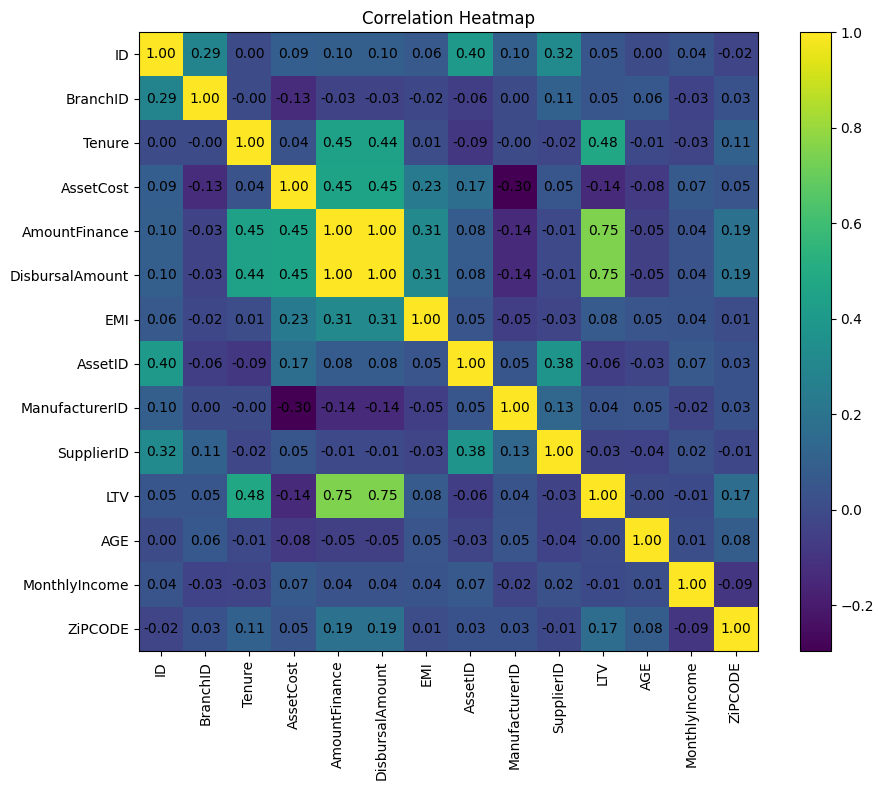

'  Example\ndf["ApplicantIncome"].corr(df["LoanAmount"]) '

In [21]:

corr_rel = df2.corr(numeric_only = True)
#print(corr_rel)
plt.figure(figsize=(10,8))
plt.imshow(corr_rel, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_rel.columns)), corr_rel.columns, rotation=90)
plt.yticks(range(len(corr_rel.columns)), corr_rel.columns)

for i in range(len(corr_rel.columns)):
    for j in range(len(corr_rel.columns)):
        plt.text(j, i, f"{corr_rel.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')


plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

"""  Example
df["ApplicantIncome"].corr(df["LoanAmount"]) """


In [41]:
#branchid,manufactureid, supplierid,area,city ,state , zipcode
print(df2.describe())

                  ID      BranchID        Tenure     AssetCost  AmountFinance  \
count   14745.000000  14745.000000  14745.000000  1.474500e+04   1.474500e+04   
mean    78115.131367    199.354900     44.945609  5.800895e+05   3.759297e+05   
min         4.000000      1.000000     10.000000  2.150000e+05   8.000000e+04   
25%     54107.000000     85.000000     36.000000  5.250000e+05   3.010020e+05   
50%     78414.000000    199.000000     46.000000  5.720000e+05   3.944050e+05   
75%    113859.000000    302.000000     48.000000  6.350000e+05   4.500000e+05   
max    143400.000000    424.000000    282.000000  1.630000e+06   1.130000e+06   
std     37441.417404    110.979557     20.214786  9.241081e+04   1.013450e+05   

       DisbursalAmount            EMI                  DisbursalDate  \
count     1.474500e+04   14745.000000                          14745   
mean      3.756281e+05   58910.209047  2015-03-28 10:59:41.688707840   
min       8.433000e+03     100.000000            2011-

In [57]:
# Active loan user area wise
active_loan = df2[df2['LoanStatus']=="Active" ] ;
print("Area wise loan count:");


#Without by
#print(active_loan.groupby('Area').size().sort_values(ascending=True).reset_index(name="Active Loan"));
Loan_pending =active_loan.groupby('Area').size().reset_index(name="Active loan").sort_values(by = "Active loan",ascending=True);
print(Loan_pending);

state_city_area = active_loan.groupby(by=["State","City","Area"]).size().reset_index(name="Active_Loans");
final_report = state_city_area.sort_values(by= ["State","City","Active_Loans"],ascending=[True,True,False]);

print("Hierarchical Active Loan Report:");
print(final_report)

Area wise loan count:
                  Area  Active loan
9             BHANDARA            1
19            FAIZABAD            1
27  HYDERABAD BEGUMPET            1
32             JODHPUR            1
52             PANIPAT            1
..                 ...          ...
34          KARIMNAGAR          139
44          MIRYALGUDA          215
0   AHMEDABAD AMBAVADI          219
17            DEHRADUN          233
37                KOTA          253

[72 rows x 2 columns]
Hierarchical Active Loan Report:
              State            City        Area  Active_Loans
0    ANDHRA PRADESH        ADILABAD  KARIMNAGAR            34
1    ANDHRA PRADESH        ADILABAD   NIZAMABAD            10
2    ANDHRA PRADESH       ANANTAPUR     NELLORE             2
3    ANDHRA PRADESH        CHITTOOR     NELLORE            16
4    ANDHRA PRADESH        CUDDAPAH     NELLORE            26
..              ...             ...         ...           ...
283     WEST BENGAL         BIRBHUM    DURGAPUR         

In [52]:
print(df2.columns)

Index(['ID', 'Frequency', 'InstlmentMode', 'LoanStatus', 'PaymentMode',
       'BranchID', 'Area', 'Tenure', 'AssetCost', 'AmountFinance',
       'DisbursalAmount', 'EMI', 'DisbursalDate', 'MaturityDAte', 'AuthDate',
       'AssetID', 'ManufacturerID', 'SupplierID', 'LTV', 'SEX', 'AGE',
       'MonthlyIncome', 'City', 'State', 'ZiPCODE', 'moving_target'],
      dtype='object')


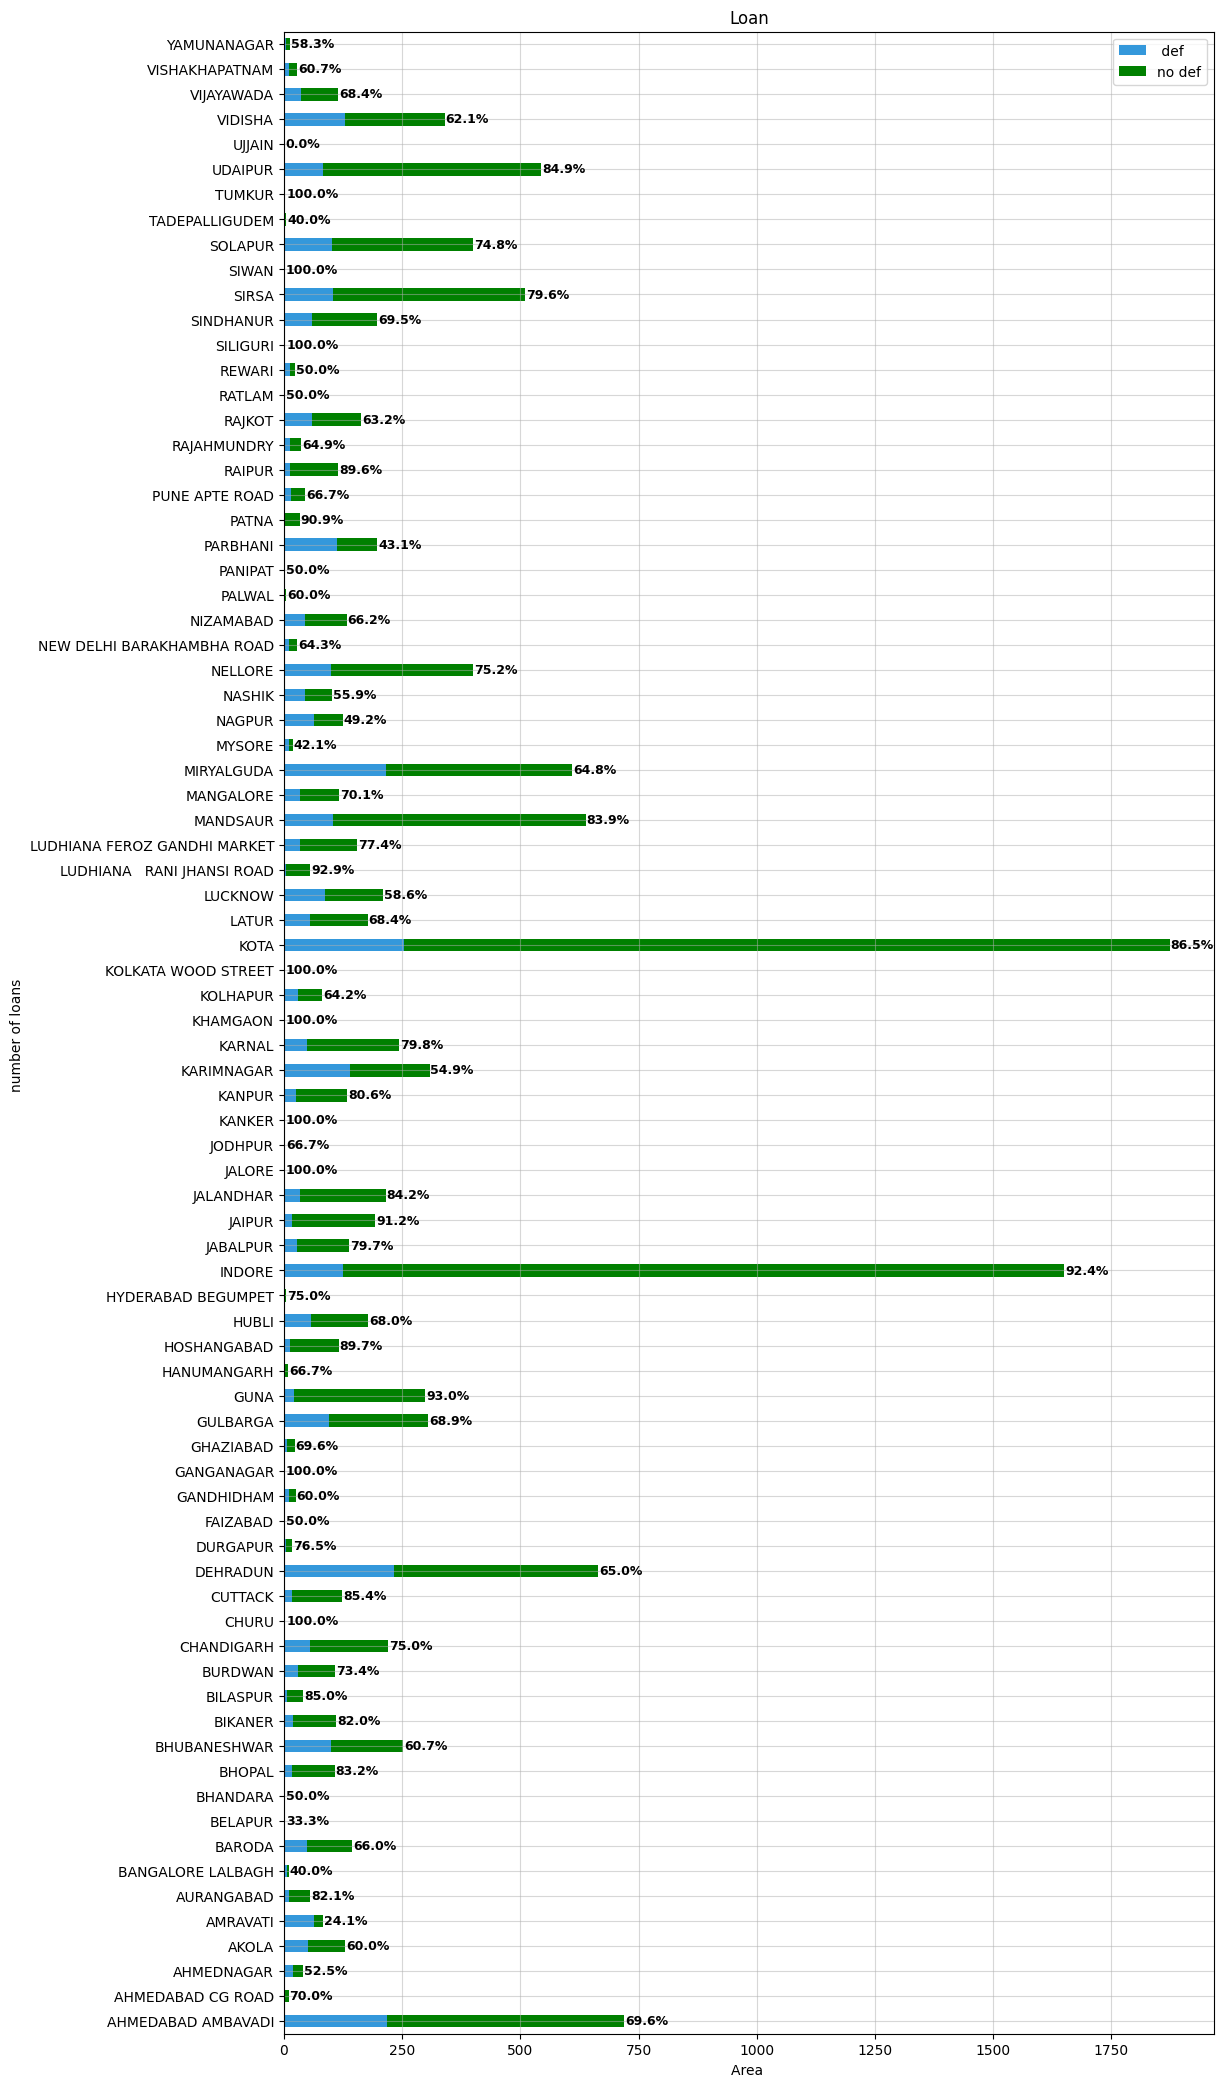

In [115]:
#Label encoding
df2['loan_num'] = df2['LoanStatus'].map({'Closed': 1 , 'Active':0 })

area_trends = pd.crosstab(df2['Area'], df2['loan_num']).fillna(0)

area_trends.plot(kind='barh', figsize=(12, 26),stacked=True, color=['#3498db', 'green'])

for i, (area_name, row) in enumerate(area_trends.iterrows()):
    active_count = row[0]
    closed_count = row[1]
    total = active_count + closed_count
    
    # Success Rate = (Closed / Total) * 100
    success_rate = (closed_count / total) * 100 if total > 0 else 0
    
    # Place text at the end of the total bar (total + small offset)
    plt.text(total + 2, i, f'{success_rate:.1f}%', va='center', fontsize=9, color='black', fontweight='bold')

plt.title("Loan")
plt.xlabel("Area ")
plt.ylabel( "number of loans ")
plt.legend([' def','no def'])
plt.grid(alpha=0.5)
plt.show()

In [4]:
#Success rate 

success = (df2['LoanStatus']== 'Closed').mean()
print(f"Overall Success Rate: {success:.2%}")



NameError: name 'df2' is not defined

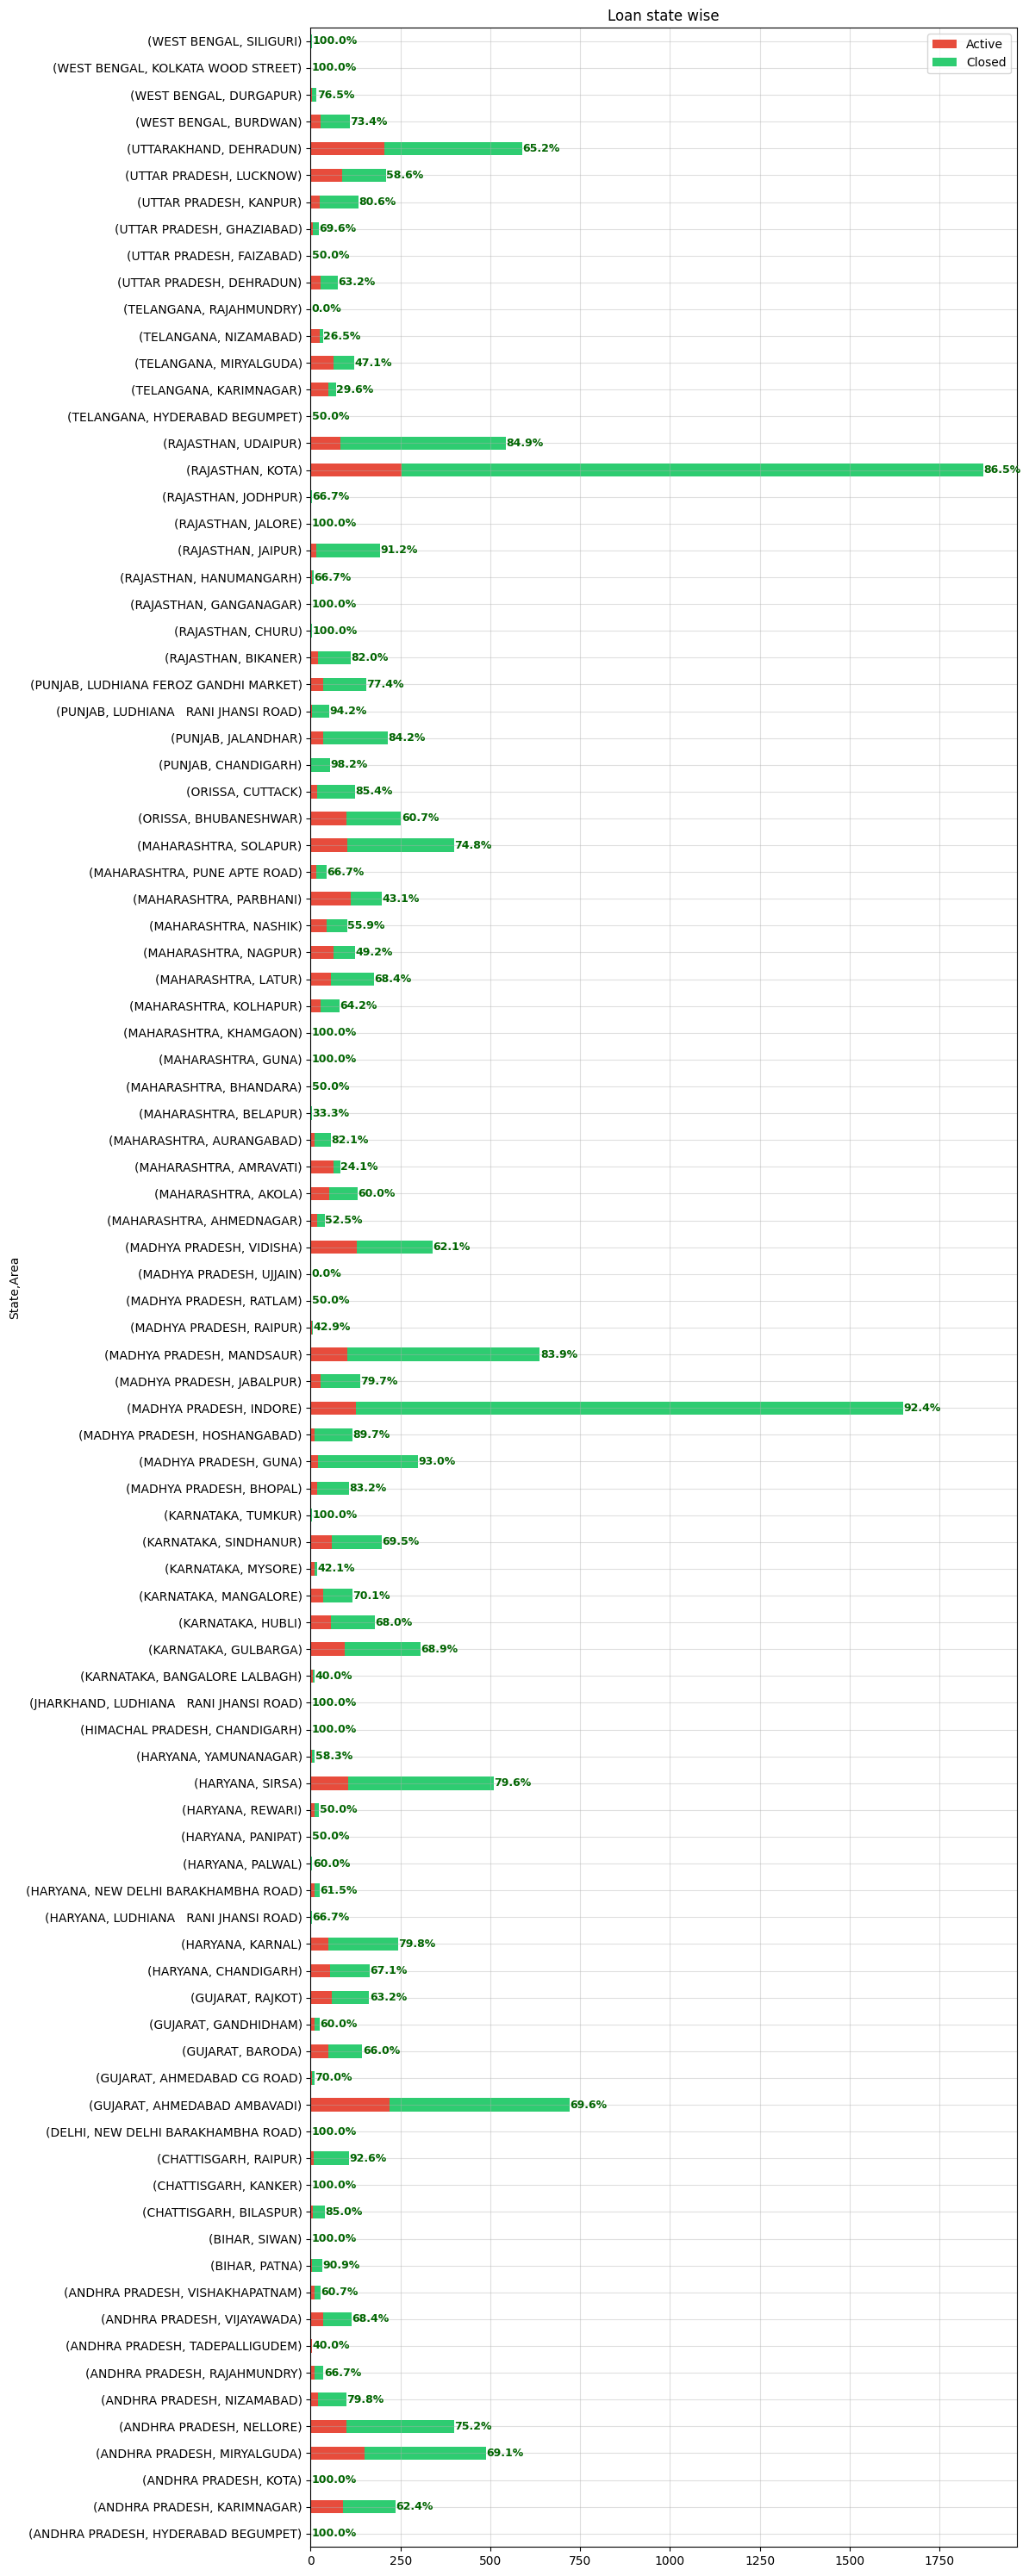

In [113]:
states_area = df2.groupby(by=['State','Area'])['LoanStatus'].value_counts().unstack().fillna(0)

states_area.plot(kind='barh',  stacked=True , figsize=(12,30) , color=['#e74c3c', '#2ecc71'])

for i, (index, row) in enumerate(states_area.iterrows()):
    total = row['Active'] + row['Closed']
    success_rate = (row['Closed'] / total) * 100 if total > 0 else 0
    
    # Place text slightly to the right of the total bar length
    # i is the vertical position (0, 1, 2...)
    plt.text(total + 1, i, f'{success_rate:.1f}%', va='center', fontsize=9, fontweight='bold', color='darkgreen')

    
plt.title("Loan state wise")
plt.legend(['Active','Closed'])
plt.grid(alpha=0.4)
plt.tight_layout()

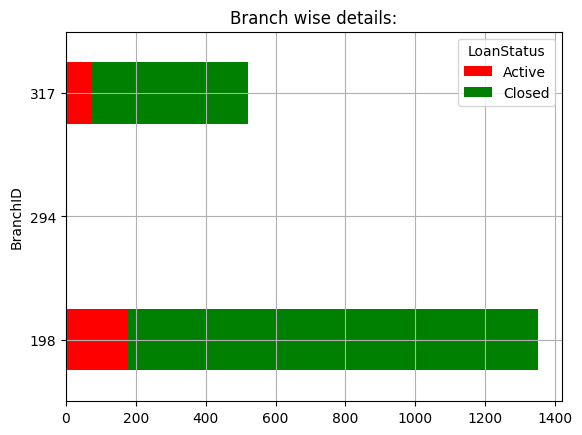

In [94]:

# star branch in kota
kota_data = df[df['Area'] == 'KOTA']

branch = kota_data.groupby('BranchID')['LoanStatus'].value_counts().unstack().fillna(0)

branch.plot(kind ='barh', color=['red','green'],stacked=True,  )
plt.title("Branch wise details:")
plt.grid()